In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [9]:
data = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\sim\sim_0.096_0.096.parquet")

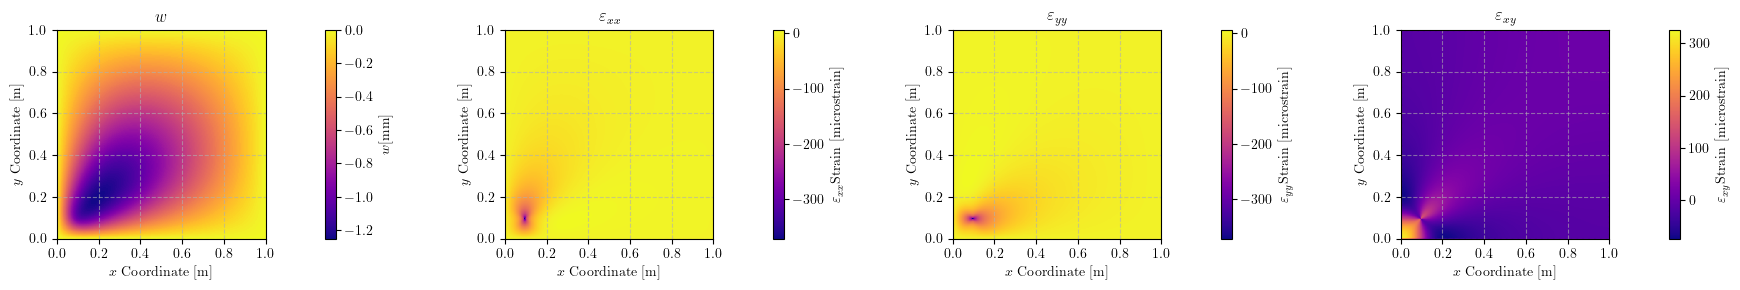

In [10]:
# Prepare data for pivoting
print_df = pd.DataFrame({
    'X': data['X'],
    'Y': data['Y'],
    'Z': data['Z'] * 1e3,
    'EXX': data['EXX'] * 1e6,
    'EYY': data['EYY'] * 1e6,
    'EXY': data['EXY'] * 1e6,
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(18, 3))

# Define the components to iterate over to avoid repeating code
components = ['Z', 'EXX', 'EYY', 'EXY']
symbol = [r'$w$', r'$\varepsilon_{xx}$', r'$\varepsilon_{yy}$', r'$\varepsilon_{xy}$']
legend = [r'$\left[\mathrm{mm}\right]$', r'Strain $\left[\mathrm{microstrain}\right]$', r'Strain $\left[\mathrm{microstrain}\right]$', r'Strain $\left[\mathrm{microstrain}\right]$',]

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    diff_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = diff_pivot.columns.to_numpy()
    y_coords = diff_pivot.index.to_numpy()
    C = diff_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]}"+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()